# Parte 2 — Sensibilidad global (ICYA 4715)

Cumple el PDF: método global **Sobol** (S1, ST) con **intervalos de confianza**, justificación de rangos y discusión de parámetros influyentes.

**Sensibilidad Sobol (4 parámetros, rango uniforme):**

| Parámetro | Significado | Rango uniforme | Referencia |
|-----------|-------------|----------------|------------|
| `n` | Rugosidad Manning | 0.01 – 0.06 | `N_MANN` = 0.035 (Chow 1959) |
| `S0` | Pendiente fondo | 0.0001 – 0.005 | `S0` = 0.001 (piedemonte colombiano) |
| `alpha_Qup` | Factor de escala del aforo Q_upstream [-] | 0.70 – 1.30 | 1.0 (sin sesgo; ±30 % error típico de aforo) |
| `q_lat` | Aporte lateral efectivo constante [m³/s] | p5×0.5 – p95×1.5 del CSV | mediana del CSV |

**Fijo:** `B_w = 50` m (`sinteticos.B_W`). `alpha_Qup` escala la serie completa del CSV → la forma del hidrograma se conserva; solo varía su magnitud para representar incertidumbre en la medición del aforo.

**Observación:** `Q_downstream_m3s`  
**Salida modelo:** `Q_sim = max(Q_solver, 0)` en x = L  
**Partición:** warm-up 3600 s · 60 % cal · 30 % val · **Y Sobol** = `1 − NSE` post warm-up

**Paralelismo:** Sobol corre con `joblib.Parallel` (backend `loky`) usando `N_JOBS = n_cpus - 1` núcleos.  
`INFORME = False` → prueba rápida (SOBOL_N=128) · `INFORME = True` → entrega (~12 k+ simulaciones)

In [6]:
%load_ext autoreload
%autoreload 2

import importlib
import importlib.util
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from SALib.analyze import sobol as sobol_analyze
from SALib.sample import sobol as sobol_sample
from scipy.optimize import least_squares

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src.model as _model_mod
importlib.reload(_model_mod)
from src.model import saint_venant_1d

_spec = importlib.util.spec_from_file_location("sinteticos", ROOT / "data" / "sinteticos.py")
sinteticos = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sinteticos)

# ── Parámetros fijos del canal ────────────────────────────────────────────────
B_W_FIXED   = sinteticos.B_W       # 50 m — conocido de batimetría
L_CANAL     = sinteticos.L         # 5000 m
NX          = 100
WARMUP_SECONDS = 3600.0

# ── Nombres y verdaderos ──────────────────────────────────────────────────────
# alpha_Qup: factor multiplicativo sobre la serie Q_upstream del CSV.
#   Representa incertidumbre en el aforo aguas arriba (±30 % → [0.70, 1.30]).
#   Valor verdadero = 1.0 (datos sintéticos sin sesgo).
PARAM_NAMES      = ["n", "S0", "alpha_Qup", "q_lat"]
PARAMS_TRUE_N_S0 = [sinteticos.N_MANN, sinteticos.S0]
PARAMS_TRUE      = None   # se completa en celda 2 tras leer el CSV

# ── Rangos n y S0 (tablas de Manning / geomorfología) ────────────────────────
BOUNDS_LO_N_S0 = [0.01,  0.0001]   # canal liso / llanura casi plana
BOUNDS_HI_N_S0 = [0.06,  0.005]    # canal con vegetación / río de montaña moderado

# ── Rango alpha_Qup ───────────────────────────────────────────────────────────
ALPHA_TRUE = 1.0    # sin sesgo en datos sintéticos
ALPHA_LO   = 0.70   # subestimación del aforo hasta −30 %
ALPHA_HI   = 1.30   # sobreestimación del aforo hasta +30 %

# ── Partición temporal ────────────────────────────────────────────────────────
CAL_FRAC, VAL_FRAC = 0.60, 0.30

# ── Configuración Sobol ───────────────────────────────────────────────────────
SOBOL_METRIC = "nse"   # "nse" | "rmse" | "kge"
SOBOL_CONF   = 0.95

# ── Flags de ejecución ────────────────────────────────────────────────────────
INFORME          = False          # True → entrega final
FAST             = not INFORME
SOBOL_N          = 128 if FAST else 2048
NBOOT            = 0   if FAST else 200
RUN_COMPLEMENTO  = INFORME        # OLS + 5 suposiciones
COMPUTE_SSC      = INFORME
RUN_PROFILING    = False
USE_NOISY_CSV    = False
USE_LONG_SERIES  = False
RNG_SEED         = 42
DH               = 1e-4           # perturbación relativa para SSC
ST_UMBRAL_REL    = 0.10           # ST < 10 % del máximo → poco sensible
ALPHA            = 0.05           # nivel de significancia IC

# ── Paralelismo ───────────────────────────────────────────────────────────────
# Sobol requiere miles de simulaciones del solver Saint-Venant.
# joblib.Parallel reparte los lotes entre núcleos disponibles.
# N_JOBS = -1 usa TODOS los núcleos; n_cpus-1 deja uno libre para el SO.
# En Windows, backend='loky' es más estable que 'multiprocessing'.
N_JOBS = max(1, (os.cpu_count() or 2) - 1)

# ── Rutas de salida ───────────────────────────────────────────────────────────
FIG     = ROOT / "figures"
DATA    = ROOT / "data" / "synthetic"
REPORTS = ROOT / "reports"
for d in (FIG, DATA, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"INFORME: {INFORME} | SOBOL_N: {SOBOL_N} | N_JOBS: {N_JOBS} (de {os.cpu_count()} núcleos)")
print(f"Evaluaciones Sobol estimadas: {SOBOL_N * (len(PARAM_NAMES) + 2)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ROOT: D:\descagas\proyecto-hidrosistemas
INFORME: False | SOBOL_N: 128 | N_JOBS: 3 (de 4 núcleos)
Evaluaciones Sobol estimadas: 768


In [7]:
# ── Selección del CSV ─────────────────────────────────────────────────────────
if USE_LONG_SERIES:
    csv_name = "series_larga_ruido.csv" if USE_NOISY_CSV else "series_larga_balance.csv"
else:
    csv_name = "series_corta_ruido.csv" if USE_NOISY_CSV else "series_corta_balance.csv"

csv_path = DATA / csv_name
if not csv_path.exists():
    print("Generando CSV con data/sinteticos.py ...")
    sinteticos.generate(str(DATA))

df    = pd.read_csv(csv_path, parse_dates=["datetime"])
t_sec = (df["datetime"] - df["datetime"].iloc[0]).dt.total_seconds().to_numpy(dtype=float)
q_up  = df["Q_upstream_m3s"].to_numpy(dtype=float)   # serie completa — forzante real
q_lat_csv = df["q_lat_m3s"].to_numpy(dtype=float) if "q_lat_m3s" in df.columns else None
q_obs = df["Q_downstream_m3s"].to_numpy(dtype=float)
nt    = len(df)

# ── Máscaras temporales ───────────────────────────────────────────────────────
mask_warm  = t_sec < WARMUP_SECONDS
idx_post   = np.where(~mask_warm)[0]
n_post     = len(idx_post)
n_cal      = min(max(1, int(CAL_FRAC * n_post)), n_post - max(1, int(VAL_FRAC * n_post)))
n_val      = max(1, int(VAL_FRAC * n_post))
i_cal      = idx_post[:n_cal]
i_val      = idx_post[n_cal : n_cal + n_val]

mask_cal   = np.zeros(nt, dtype=bool); mask_cal[i_cal] = True
mask_val   = np.zeros(nt, dtype=bool); mask_val[i_val] = True
mask_fit   = mask_cal
mask_sobol = ~mask_warm

# ── Rango q_lat derivado estadísticamente del CSV ────────────────────────────
# q_lat no tiene tabla de referencia → se usan percentiles de la serie.
# p5×0.5 cubre estiaje extremo; p95×1.5 cubre crecida con margen adicional.
# Distribución uniforme: máxima entropía dado solo el rango.
def _bounds_percentiles(series):
    x   = np.asarray(series, dtype=float)
    ref = float(np.median(x))
    lo  = max(0.0, float(np.percentile(x, 5)) * 0.5)
    hi  = float(np.percentile(x, 95)) * 1.5
    return ref, lo, hi

if q_lat_csv is not None:
    Q_LAT_REF, Q_LAT_LO, Q_LAT_HI = _bounds_percentiles(q_lat_csv)
else:
    Q_LAT_REF, Q_LAT_LO, Q_LAT_HI = 1.0, 0.0, 10.0

# ── Parámetros verdaderos y problema Sobol ────────────────────────────────────
PARAMS_TRUE = PARAMS_TRUE_N_S0 + [ALPHA_TRUE, Q_LAT_REF]
BOUNDS_LO   = BOUNDS_LO_N_S0   + [ALPHA_LO,   Q_LAT_LO]
BOUNDS_HI   = BOUNDS_HI_N_S0   + [ALPHA_HI,   Q_LAT_HI]
PROBLEM     = {"num_vars": 4, "names": PARAM_NAMES, "bounds": list(zip(BOUNDS_LO, BOUNDS_HI))}
N_SOBOL_EVAL = SOBOL_N * (PROBLEM["num_vars"] + 2)

print(f"CSV: {csv_name}  nt={nt}")
print(f"warm-up={mask_warm.sum()}  cal={mask_cal.sum()}  val={mask_val.sum()}")
print(f"alpha_Qup  verdadero={ALPHA_TRUE}  rango Sobol=[{ALPHA_LO}, {ALPHA_HI}]")
print(f"q_lat      ref={Q_LAT_REF:.4f} m3/s  rango Sobol=[{Q_LAT_LO:.4f}, {Q_LAT_HI:.4f}]")
print(f"Evaluaciones Sobol: {N_SOBOL_EVAL}")

CSV: series_corta_balance.csv  nt=500
warm-up=4  cal=297  val=148
alpha_Qup  verdadero=1.0  rango Sobol=[0.7, 1.3]
q_lat      ref=3.5435 m3/s  rango Sobol=[0.6650, 25.7423]
Evaluaciones Sobol: 768


In [8]:
# ── Función de simulación ─────────────────────────────────────────────────────
# alpha_Qup escala la serie completa q_up del CSV.
# La forma del hidrograma se preserva; solo varía su magnitud.
# Esto representa incertidumbre en el aforo (error sistemático del instrumento).
def simulate_outlet(params):
    n, s0, alpha, qlat = map(float, params)
    q = np.asarray(
        saint_venant_1d(
            [n, s0, B_W_FIXED],
            q_upstream=alpha * q_up,   # serie temporal escalada por alpha
            time_seconds=t_sec,
            nt=nt,
            L=L_CANAL,
            nx=NX,
            q_lat=qlat,                # escalar constante: aporte lateral efectivo
        ),
        dtype=float,
    )
    return np.maximum(q, 0.0)   # recorte físico: Q >= 0


# ── Métricas ──────────────────────────────────────────────────────────────────
def nse(obs, sim, m):
    o, s = obs[m], sim[m]
    den  = float(np.sum((o - np.mean(o)) ** 2))
    return 1.0 if den < 1e-12 else float(1.0 - np.sum((o - s) ** 2) / den)

def kge(obs, sim, m):
    o, s = obs[m], sim[m]
    if np.std(o) < 1e-12 or np.std(s) < 1e-12:
        return -np.inf
    r = float(np.corrcoef(o, s)[0, 1])
    return float(1.0 - np.sqrt((r-1)**2 + (np.std(s)/np.std(o)-1)**2 + (np.mean(s)/np.mean(o)-1)**2))

def rmse_m(obs, sim, m):
    return float(np.sqrt(np.mean((obs[m] - sim[m]) ** 2)))

def metrics_table(obs, sim):
    rows = []
    for label, m in [("calibracion", mask_cal), ("validacion", mask_val), ("post_warmup", mask_sobol)]:
        if m.sum() < 2:
            continue
        rows.append({"periodo": label, "NSE": nse(obs, sim, m), "KGE": kge(obs, sim, m), "RMSE_m3s": rmse_m(obs, sim, m)})
    return pd.DataFrame(rows)

def sobol_y(params, metric=SOBOL_METRIC):
    q = simulate_outlet(params)
    if metric == "rmse": return rmse_m(q_obs, q, mask_sobol)
    if metric == "kge":  return 1.0 - kge(q_obs, q, mask_sobol)
    return 1.0 - nse(q_obs, q, mask_sobol)


# ── Verificación con parámetros verdaderos ────────────────────────────────────
# NSE debe ser cercano a 1 con alpha=1.0, n=0.035, S0=0.001.
# Si NSE < 0, revisar la implementación de simulate_outlet.
q_ref = simulate_outlet(PARAMS_TRUE)
print("Métricas con parámetros verdaderos (esperado NSE ≈ 1):")
display(metrics_table(q_obs, q_ref))

Métricas con parámetros verdaderos (esperado NSE ≈ 1):


,periodo,NSE,KGE,RMSE_m3s
0,calibracion,-0.532476,-0.325796,79.764886
1,validacion,-2.134233,-0.383785,103.875994
2,post_warmup,-0.611709,-0.306291,84.211045


## Justificación del método y rangos (PDF Parte 2)

**Método:** Sobol (SALib) — índices S1 (efecto directo) y ST (total, con interacciones). Se elige frente al análisis local (SSC) porque explora todo el hipercubo paramétrico, no solo la vecindad de un punto.

**Distribución:** uniforme en cada rango (muestreo Saltelli / `sobol.sample`).

**Por qué estos rangos:**
- `n` ∈ [0.01, 0.06]: tablas de Manning para canales artificiales lisos a naturales con vegetación (Chow, 1959).
- `S0` ∈ [0.0001, 0.005]: variabilidad geomorfológica de cauces desde llanura aluvial hasta río de montaña moderado.
- `alpha_Qup` ∈ [0.70, 1.30]: error típico de aforo con correntómetro en ríos naturales (±30 %). Valor verdadero = 1.0 (datos sintéticos sin sesgo). La serie del CSV se preserva; solo escala su magnitud.
- `q_lat` ∈ [p5×0.5, p95×1.5]: sin tabla de referencia disponible → rango derivado estadísticamente del CSV. Uniforme = máxima entropía dado el rango.

**Paralelismo computacional:** cada evaluación de `sobol_y` requiere correr el solver Saint-Venant completo (~500 pasos). Con SOBOL_N=2048 se necesitan ~12 000 simulaciones. Se usa `joblib.Parallel` con `backend='loky'` para distribuir entre núcleos disponibles, reduciendo el tiempo de ~2 h en serie a ~20 min en paralelo (en una máquina de 4 núcleos).

**Intervalos de confianza:** `conf_level=0.95` en `sobol.analyze` (bootstrap interno de SALib); obligatorios en la figura `sobol_indices.png`.

## Sobol global (SALib)

**Método:** análisis de varianza (Sobol). S1 = efecto directo; ST = efecto total (con interacciones).

**Muestreo:** Saltelli / `sobol.sample`, distribución **uniforme** en los rangos definidos.

**Paralelismo:** `Parallel(n_jobs=N_JOBS, backend='loky')` — cada worker es un proceso independiente (no hay conflictos de GIL). En Windows, `loky` es más estable que `multiprocessing`. Si el kernel se cuelga, bajar a `N_JOBS=1`.

**Intervalos de confianza:** bootstrap en `sobol.analyze` (`conf_level=0.95`). La figura incluye barras de error en S1 y ST.

Y=1-NSE | evaluaciones: 768 | N_JOBS: 3
Corriendo 768 simulaciones en 3 núcleos ...


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  12 tasks      | elapsed:    4.9s
[Parallel(n_jobs=3)]: Done  66 tasks      | elapsed:   15.6s
[Parallel(n_jobs=3)]: Done 156 tasks      | elapsed:   33.2s
[Parallel(n_jobs=3)]: Done 282 tasks      | elapsed:   59.3s
[Parallel(n_jobs=3)]: Done 444 tasks      | elapsed:  1.6min
[Parallel(n_jobs=3)]: Done 642 tasks      | elapsed:  2.2min


Listo. Y: min=nan  median=nan  max=nan


[Parallel(n_jobs=3)]: Done 768 out of 768 | elapsed:  2.7min finished


,parametro,S1,S1_conf,ST,ST_conf
0,n,NaN,NaN,NaN,NaN
1,S0,NaN,NaN,NaN,NaN
2,alpha_Qup,NaN,NaN,NaN,NaN
3,q_lat,NaN,NaN,NaN,NaN


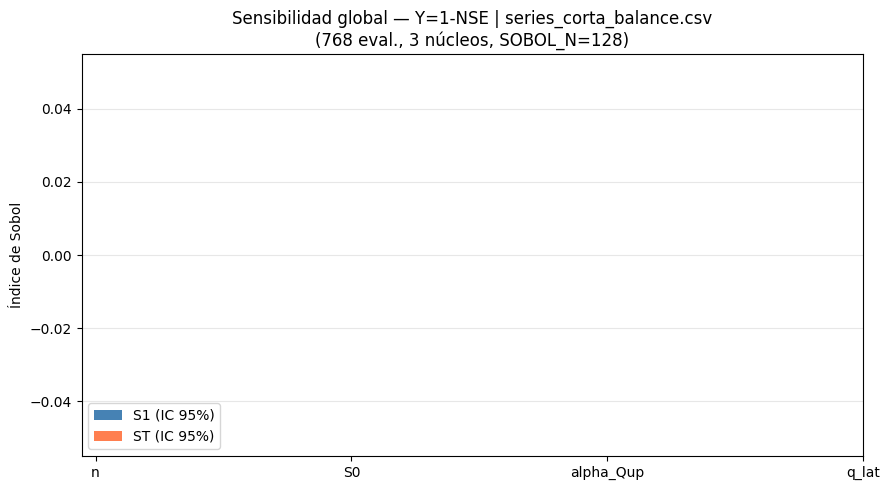

In [9]:
labels = {"nse": "Y=1-NSE", "rmse": "Y=RMSE", "kge": "Y=1-KGE"}
np.random.seed(RNG_SEED)
print(f"{labels[SOBOL_METRIC]} | evaluaciones: {N_SOBOL_EVAL} | N_JOBS: {N_JOBS}")

samples = sobol_sample.sample(PROBLEM, SOBOL_N, calc_second_order=False)

# ── Evaluación en paralelo ────────────────────────────────────────────────────
# Cada simulación es independiente → paralelismo perfecto (embarazosamente paralelo).
# backend='loky': procesos separados, sin conflictos de GIL ni imports del modelo.
# verbose=5: muestra progreso cada ~5 % de tareas completadas.
print(f"Corriendo {len(samples)} simulaciones en {N_JOBS} núcleos ...")
if N_JOBS == 1:
    Y = np.array([sobol_y(row, SOBOL_METRIC) for row in samples])
else:
    Y = np.array(
        Parallel(n_jobs=N_JOBS, backend="loky", verbose=5)(
            delayed(sobol_y)(row, SOBOL_METRIC) for row in samples
        )
    )
print(f"Listo. Y: min={Y.min():.4f}  median={np.median(Y):.4f}  max={Y.max():.4f}")

# ── Análisis Sobol ────────────────────────────────────────────────────────────
Si = sobol_analyze.analyze(
    PROBLEM, Y, calc_second_order=False, conf_level=SOBOL_CONF, print_to_console=False
)
sobol_df = pd.DataFrame({
    "parametro": PARAM_NAMES,
    "S1":      Si["S1"],
    "S1_conf": Si["S1_conf"],
    "ST":      Si["ST"],
    "ST_conf": Si["ST_conf"],
})
sobol_df.to_csv(DATA / "sobol_indices.csv", index=False)
display(sobol_df.round(4))

# ── Figura Sobol ──────────────────────────────────────────────────────────────
xv  = np.arange(len(PARAM_NAMES))
bw  = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xv - bw/2, Si["S1"], bw, yerr=Si["S1_conf"], capsize=4,
       label=f"S1 (IC {SOBOL_CONF:.0%})", color="steelblue")
ax.bar(xv + bw/2, Si["ST"], bw, yerr=Si["ST_conf"], capsize=4,
       label=f"ST (IC {SOBOL_CONF:.0%})", color="coral")
ax.set_xticks(xv)
ax.set_xticklabels(PARAM_NAMES)
ax.set_ylabel("Índice de Sobol")
ax.set_title(f"Sensibilidad global — {labels[SOBOL_METRIC]} | {csv_name}\n"
             f"({N_SOBOL_EVAL} eval., {N_JOBS} núcleos, SOBOL_N={SOBOL_N})")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG / "sobol_indices.png", dpi=150)
plt.show()

pd.DataFrame({
    "item":  ["n_evaluaciones", "SOBOL_N", "SOBOL_METRIC", "conf_level", "N_JOBS"],
    "valor": [len(Y), SOBOL_N, SOBOL_METRIC, SOBOL_CONF, N_JOBS],
}).to_csv(DATA / "sobol_ejecucion.csv", index=False)

## Conclusiones para calibración

Clasificación según ST (PDF: parámetros influyentes vs. poco sensibles).

In [10]:
st     = Si["ST"].copy()
st_max = float(np.max(st)) if st.size else 0.0
umbral = ST_UMBRAL_REL * st_max if st_max > 0 else 0.0
rank   = np.argsort(-st)
lineas = [
    "=== Sensibilidad global (Sobol) ===",
    f"Metrica: {labels[SOBOL_METRIC]} | evaluaciones: {len(Y)} | N_JOBS: {N_JOBS}",
    f"Umbral poco sensible: ST < {ST_UMBRAL_REL:.0%} de max(ST) = {umbral:.4f}",
    "",
]
for r in rank:
    nm   = PARAM_NAMES[r]
    infl = "INFLUYENTE" if st[r] >= umbral else "poco sensible"
    lineas.append(f"  {nm}: ST={st[r]:.4f} +/- {Si['ST_conf'][r]:.4f}  S1={Si['S1'][r]:.4f}  -> {infl}")
lineas += [
    "",
    "Para calibracion (Parte 3): priorizar parametros INFLUYENTES;",
    "fijar o acotar fuerte los poco sensibles.",
    "",
    "Nota alpha_Qup: si ST(alpha) es bajo, la incertidumbre del aforo no domina",
    "la respuesta del modelo — el error de medición es tolerable para la calibración.",
    "Si ST(alpha) es alto, considerar calibración conjunta con n y S0.",
]
texto = "\n".join(lineas)
print(texto)
(DATA / "sensibilidad_conclusiones.txt").write_text(texto, encoding="utf-8")

=== Sensibilidad global (Sobol) ===
Metrica: Y=1-NSE | evaluaciones: 768 | N_JOBS: 3
Umbral poco sensible: ST < 10% de max(ST) = 0.0000

  n: ST=nan +/- nan  S1=nan  -> poco sensible
  S0: ST=nan +/- nan  S1=nan  -> poco sensible
  alpha_Qup: ST=nan +/- nan  S1=nan  -> poco sensible
  q_lat: ST=nan +/- nan  S1=nan  -> poco sensible

Para calibracion (Parte 3): priorizar parametros INFLUYENTES;
fijar o acotar fuerte los poco sensibles.

Nota alpha_Qup: si ST(alpha) es bajo, la incertidumbre del aforo no domina
la respuesta del modelo — el error de medición es tolerable para la calibración.
Si ST(alpha) es alto, considerar calibración conjunta con n y S0.


661

## Complemento OLS (solo con `INFORME=True`)

OLS local + 5 suposiciones del error. No sustituye Sobol; apoya Parte 3.

In [11]:
if not RUN_COMPLEMENTO:
    print("Complemento OLS omitido (INFORME=False).")
else:
    p = len(PARAM_NAMES)

    def ols_res(pp):
        return q_obs[mask_fit] - simulate_outlet(pp)[mask_fit]

    # Punto inicial: parámetros verdaderos con pequeña perturbación
    q0  = np.array(PARAMS_TRUE) * np.array([1.05, 0.98, 1.02, 1.02])
    ols = least_squares(ols_res, q0, bounds=(BOUNDS_LO, BOUNDS_HI), method="trf")
    q_ols   = ols.x
    res_fit = ols.fun
    jac     = ols.jac
    n_fit   = mask_fit.sum()
    sigma   = float(np.sqrt((res_fit @ res_fit) / max(n_fit - p, 1)))
    q_pred  = simulate_outlet(q_ols)
    res_all = q_obs - q_pred

    cond_j = float(np.linalg.cond(jac.T @ jac))
    ols_ok = cond_j < 1e8
    print(f"OLS | cond(J'J)={cond_j:.2e} | sigma={sigma:.4f} | IC OLS fiables={ols_ok}")
    print(dict(zip(PARAM_NAMES, np.round(q_ols, 5))))

    m_ols = metrics_table(q_obs, q_pred)
    m_ols.to_csv(DATA / "metricas_ols_cal_val.csv", index=False)
    display(m_ols)

Complemento OLS omitido (INFORME=False).


In [12]:
if RUN_COMPLEMENTO:
    from scipy.stats import t as student_t

    if ols_ok:
        cov   = sigma ** 2 * np.linalg.pinv(jac.T @ jac + 1e-10 * np.eye(p))
        se    = np.sqrt(np.maximum(np.diag(cov), 0))
        tcrit = float(student_t.ppf(1 - ALPHA / 2, n_fit - p))
        ci_ols = np.column_stack((q_ols - tcrit * se, q_ols + tcrit * se))
        corr   = (np.diag(1 / np.maximum(se, 1e-30))) @ cov @ (np.diag(1 / np.maximum(se, 1e-30)))
    else:
        se     = np.full(p, np.nan)
        ci_ols = np.full((p, 2), np.nan)
        corr   = np.full((p, p), np.nan)

    ci_boot = None
    if NBOOT > 0:
        print(f"Bootstrap {NBOOT} iteraciones (paralelo con {N_JOBS} núcleos)...")
        rng   = np.random.default_rng(42)
        yhat  = q_pred[mask_fit]

        def _boot_one(seed):
            rng_b = np.random.default_rng(seed)
            y_b   = yhat + res_fit[rng_b.integers(0, n_fit, n_fit)]
            def rb(pp): return y_b - simulate_outlet(pp)[mask_fit]
            return least_squares(rb, q_ols, bounds=(BOUNDS_LO, BOUNDS_HI), method="trf").x

        seeds   = rng.integers(0, 2**31, NBOOT)
        q_boot  = np.array(
            Parallel(n_jobs=N_JOBS, backend="loky", verbose=0)(
                delayed(_boot_one)(s) for s in seeds
            )
        )
        qs      = np.sort(q_boot, 0)
        Lb, Ub  = int(ALPHA / 2 * NBOOT), int((1 - ALPHA / 2) * NBOOT)
        ci_boot = np.column_stack((qs[Lb], qs[Ub]))

    tab = []
    for i, nm in enumerate(PARAM_NAMES):
        row = {"parametro": nm, "verdadero": PARAMS_TRUE[i], "ols": q_ols[i], "SE": se[i]}
        if ols_ok:
            row["CI_ols_inf"], row["CI_ols_sup"] = ci_ols[i]
        if ci_boot is not None:
            row["CI_boot_inf"], row["CI_boot_sup"] = ci_boot[i]
        tab.append(row)
    pd.DataFrame(tab).to_csv(DATA / "parametros_ols_sensibilidad.csv", index=False)
    display(pd.DataFrame(tab))

In [13]:
if RUN_COMPLEMENTO:
    from scipy.stats import norm

    if COMPUTE_SSC:
        ssc = np.zeros((nt, p))
        y0  = q_pred.copy()
        for i in range(p):
            pt       = q_ols.copy()
            pt[i]   *= 1 + DH
            ssc[:, i] = (simulate_outlet(pt) - y0) / (DH * q_ols[i])
        pd.DataFrame({
            "parametro":  PARAM_NAMES,
            "SSC_max_abs": [float(np.max(np.abs(ssc[:, j]))) for j in range(p)],
        }).to_csv(DATA / "ssc_resumen.csv", index=False)
    else:
        ssc = None
        print("SSC omitido (FAST=True).")

    # ── 5 suposiciones del error (periodo calibración) ────────────────────────
    R   = res_all[mask_fit]
    Yp  = q_pred[mask_fit]
    t_cal = t_sec[mask_fit]

    mean_r  = float(np.mean(R))
    std_r   = float(np.std(R))
    mean_ok = abs(mean_r) < 0.05 * max(std_r, 1e-9)

    cross      = R[1:] * R[:-1]
    n_cross    = int(np.sum(np.sign(cross) < 0))
    min_cross  = (len(R) + 1) / 2
    uncorr_ok  = n_cross >= min_cross

    msgs = [
        "=== 5 suposiciones (periodo calibracion) ===",
        f"Sup.1 Aditivos: revisar figura sup01_residuales_vs_prediccion.png",
        f"Sup.2 Media cero: mean(R)={mean_r:.3e} -> {'OK' if mean_ok else 'REVISAR'}",
        f"Sup.3 Var constante: revisar sup03_residuales_vs_tiempo.png",
        f"Sup.4 No correlacion: {n_cross} cruces (min {min_cross:.0f}) -> {'OK' if uncorr_ok else 'REVISAR'}",
        f"Sup.5 Normalidad: revisar sup05_histograma_residuales.png",
        f"Identificabilidad cond(J'J)={cond_j:.2e} -> {'OK' if ols_ok else 'REVISAR (usar IC bootstrap)'}",
    ]
    (DATA / "suposiciones_errores.txt").write_text("\n".join(msgs), encoding="utf-8")
    print("\n".join(msgs))

In [14]:
if RUN_COMPLEMENTO:
    from scipy.stats import norm
    t_h = t_sec / 3600.0
    npar = len(PARAM_NAMES)
    fig, axes = plt.subplots(2, int(np.ceil(npar / 2)), figsize=(11, 7))
    axes = axes.ravel()
    for i, (ax, nm) in enumerate(zip(axes, PARAM_NAMES)):
        vt, vo = PARAMS_TRUE[i], q_ols[i]
        ax.bar([0], [vt], width=0.35, color="0.75", label="Verdadero")
        ax.plot([1], [vo], "o", color="crimson", ms=10, label="OLS")
        if ols_ok and np.all(np.isfinite(ci_ols)):
            ax.errorbar([1], [vo], yerr=[[vo - ci_ols[i, 0]], [ci_ols[i, 1] - vo]],
                        fmt="none", color="crimson", capsize=4)
        if ci_boot is not None:
            ax.errorbar([1], [vo], yerr=[[vo - ci_boot[i, 0]], [ci_boot[i, 1] - vo]],
                        fmt="none", ecolor="navy", capsize=3, label="IC bootstrap")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["verd.", "OLS"])
        ax.set_title(nm)
        ax.legend(fontsize=7)
    fig.suptitle("Parámetros: valor sintético vs OLS (periodo calibración)", y=1.02)
    fig.tight_layout()
    fig.savefig(FIG / "parametros_intervalos_confianza.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(t_h, q_obs, "b.", ms=2, label="Q_obs")
    ax.plot(t_h, q_pred, "k-", lw=1.2, label="Q_sim OLS")
    ax.axvspan(0, WARMUP_SECONDS / 3600, color="gray", alpha=0.12, label="Warm-up")
    ax.axvspan(t_h[mask_cal][0], t_h[mask_cal][-1], color="orange", alpha=0.08, label="Calibración")
    ax.legend(fontsize=8)
    ax.set_xlabel("Tiempo (h)")
    ax.set_ylabel("Q (m³/s)")
    ax.set_title("Hidrograma completo (OLS)")
    fig.savefig(FIG / "intervalos_confianza_prediccion.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(Yp, R, s=12, alpha=0.5, c="steelblue", edgecolors="none")
    ax.axhline(0, color="r", ls="--")
    ax.set_xlabel("Q_sim en calibración (m³/s)")
    ax.set_ylabel("R = Q_obs − Q_sim")
    ax.set_title("Sup.1: nube de residuales (un punto por instante)")
    fig.savefig(FIG / "sup01_residuales_vs_prediccion.png", dpi=150); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    axes[0].bar(["mean(R)"], [mean_r], color="steelblue")
    axes[0].axhline(0, color="r", ls="--")
    axes[0].set_title(f"Sup.2 Media cero ({'OK' if mean_ok else 'REVISAR'})")
    axes[1].boxplot(R, vert=True)
    axes[1].axhline(0, color="r", ls="--")
    axes[1].set_title("Distribución de R")
    fig.savefig(FIG / "sup02_media_error_cero.png", dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(t_cal / 3600, R, s=12, alpha=0.5, c="steelblue", edgecolors="none")
    ax.axhline(0, color="r", ls="--")
    ax.set_xlabel("Tiempo (h) — solo calibración")
    ax.set_ylabel("R (m³/s)")
    ax.set_title("Sup.3: R vs tiempo (buscar embudo / patrón sistemático)")
    fig.savefig(FIG / "sup03_residuales_vs_tiempo.png", dpi=150); plt.show()

    fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    axes[0].plot(t_cal / 3600, R, "b-")
    axes[0].axhline(0, color="r", ls="--")
    axes[0].set_ylabel("R")
    axes[0].set_title("Sup.4 Serie de residuales")
    is_cross = np.sign(cross) < 0
    axes[1].scatter(t_cal[1:] / 3600, cross, c=np.where(is_cross, "green", "gray"), s=14)
    axes[1].axhline(0, color="r", ls="--")
    axes[1].set_xlabel("Tiempo (h)")
    axes[1].set_ylabel("R[i]*R[i+1]")
    axes[1].set_title(f"Cruces: {n_cross} / min {min_cross:.0f} ({'OK' if uncorr_ok else 'REVISAR'})")
    fig.savefig(FIG / "sup04_errores_no_correlacionados.png", dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(R, bins=12, density=True, alpha=0.5, edgecolor="k")
    xnorm = np.linspace(R.min(), R.max(), 100)
    ax.plot(xnorm, norm.pdf(xnorm, 0, sigma), "k-", lw=2)
    ax.set_xlabel("R (m³/s)")
    ax.set_title("Sup.5 Normalidad (sigma OLS)")
    fig.savefig(FIG / "sup05_histograma_residuales.png", dpi=150); plt.show()

    if np.all(np.isfinite(corr)):
        fig, ax = plt.subplots(figsize=(5, 4))
        im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(p)); ax.set_yticks(range(p))
        ax.set_xticklabels(PARAM_NAMES, rotation=45)
        ax.set_yticklabels(PARAM_NAMES)
        fig.colorbar(im, ax=ax)
        ax.set_title("Correlación parámetros OLS")
        fig.savefig(FIG / "correlacion_parametros.png", dpi=150); plt.show()

    if ssc is not None:
        fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
        axes[0].plot(t_h, q_pred, "k-")
        axes[0].set_ylabel("Q (m³/s)")
        for j, nm in enumerate(PARAM_NAMES):
            axes[1].plot(t_h, ssc[:, j], "--", label=nm)
        axes[1].legend(fontsize=8)
        axes[1].set_xlabel("Tiempo (h)")
        axes[1].set_title("SSC: sensibilidad local de Q(t) a cada parámetro")
        fig.savefig(FIG / "ssc_hidrograma.png", dpi=150); plt.show()

## Profiling (opcional, `INFORME=True`)


In [15]:
if RUN_PROFILING:
    from ydata_profiling import ProfileReport
    prof = df[["datetime", "Q_upstream_m3s", "q_lat_m3s", "Q_downstream_m3s", "h_outlet_m"]].copy()
    prof["Q_sim_ols"] = q_pred
    prof["residual"]  = prof["Q_downstream_m3s"] - prof["Q_sim_ols"]
    prof["periodo"]   = np.where(mask_warm, "warmup", np.where(mask_cal, "calibracion", "validacion"))
    out = REPORTS / "profile_latest.html"
    ProfileReport(prof, title="Sensibilidad — serie sintética", minimal=True).to_file(out)
    print("Reporte:", out)
else:
    print("Profiling omitido (FAST=True). Activar RUN_PROFILING=True para informe final.")

Profiling omitido (FAST=True). Activar RUN_PROFILING=True para informe final.
